ARTI-309 - Mathematical Foundations for AI
# Gradient Descent on Single-Variable Functions

In this section, we implement Gradient Descent on single-variable functions.  
The goal is to find the minimum value of a function by iteratively updating the variable in the opposite direction of the gradient.

We analyze different types of functions to understand how the shape of the function affects convergence speed and behavior.

## Gradient Descent Rule

The update rule used in this experiment is:

$$
x_{k+1} = x_k - \alpha f'(x_k)
$$



### Where:

- $x_k$ : current value at iteration $k$  
- $x_{k+1}$ : updated value  
- $\alpha$ : learning rate (step size)  
- $f'(x_k)$ : derivative (gradient) of the function  

> The algorithm updates the value of $x$ by moving in the opposite direction of the gradient in order to minimize the function.

## 1. Importing Libraries

The following libraries are used for numerical computation and visualization:

- **NumPy** → used for mathematical operations and array handling  
- **Matplotlib** → used for plotting graphs and visualizing results  
- **Seaborn** → used for improving the visual style of plots

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

## 2. Functions Definition

In this experiment, we analyze four different functions:

### 1. Quadratic Function
$$
f(x) = x^2
$$

### 2. Quartic Function
$$
f(x) = x^4
$$

### 3. Non-Convex Function
$$
f(x) = x^4 - 3x^2 + 2
$$

### 4. Sinusoidal Function
$$
f(x) = \sin(2x)\cos(2x) + 0.2x^2
$$

In [13]:
# f1(x) = x^2
def f1(x): return x**2

# f1'(x) = 2x
def df1(x): return 2*x


# f2(x) = x^4
def f2(x): return x**4

# f2'(x) = 4x^3
def df2(x): return 4*x**3


# f3(x) = x^4 - 3x^2 + 2
def f3(x): return x**4 - 3*x**2 + 2

# f3'(x) = 4x^3 - 6x
def df3(x): return 4*x**3 - 6*x

# f4(x) = sin(2x) * cos(2x) + 0.2x^2
def f4(x): return np.sin(2*x)*np.cos(2*x) + 0.2*(x**2)

# f4'(x) = 2cos(2x)cos(2x) - 2sin(2x)sin(2x) + 0.4x
def df4(x): return 2*np.cos(2*x)**2 - 2*np.sin(2*x)**2 + 0.4*x

## 3. Gradient Function

In [14]:
def gradient_descent(f, df, x0, lr, iterations):
    x = x0                  # initialize starting value
    points = [x]            # store the path of x values

    for i in range(iterations):   # loop for a fixed number of steps
        grad = df(x)              # compute the gradient (slope)
        x = x - lr * grad         # update x using gradient descent rule
        points.append(x)          # save updated x value

        # stopping condition
        if abs(grad) < 1e-6:      # stop if gradient is very small (near minimum)
            break

    return points                # return all x values during optimization

## 4. Experiment Setup

In [15]:
# different starting points to test how initial value affects convergence
initial_values = [-5, -1, 5]

# different step sizes to analyze slow, normal, and unstable updates
learning_rates = [0.001, 0.1]

## 5. Results

### 5.1 Quadratic Function
$$
f(x) = x^2
$$

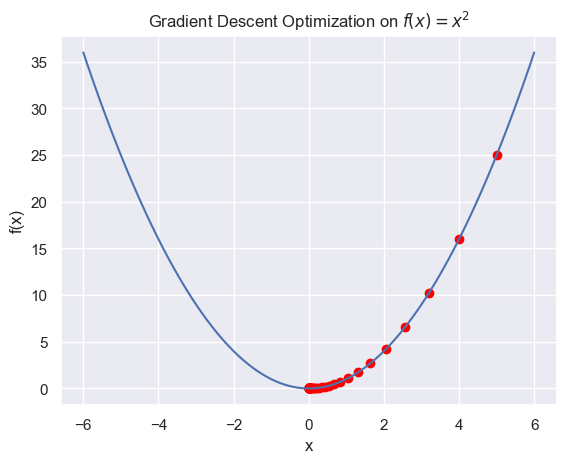

In [16]:
# run gradient descent starting from x = 5 with learning rate = (0.1), for 5000 iterations
path1 = gradient_descent(f1, df1, initial_values[2], learning_rates[1], 5000)

x_vals = np.linspace(-6, 6, 100) # generate x values for plotting the function
y_vals = f1(x_vals)              # compute corresponding y values using f(x) = x^2

# plot the function curve (blue line)
plt.plot(x_vals, y_vals)

# plot gradient descent steps as red points
plt.scatter(path1, [f1(x) for x in path1], color='red')

plt.title(r"Gradient Descent Optimization on $f(x) = x^2$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

### 5.2 Quartic Function
$$
f(x) = x^4
$$

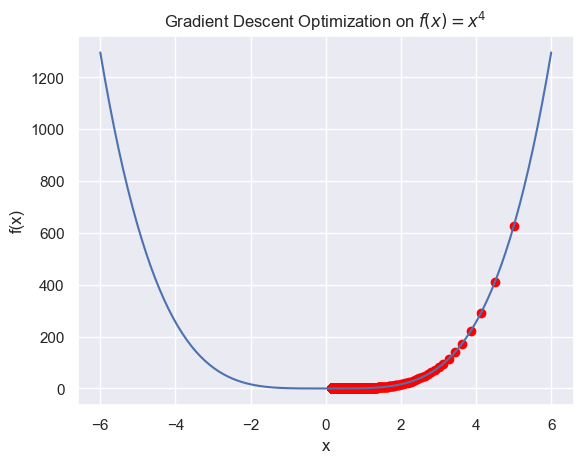

In [17]:
# run gradient descent on f(x) = x^4 starting from x = 5 with learning rate (0.001), for 5000 iterations
path2 = gradient_descent(f2, df2, initial_values[2], learning_rates[0], 5000)

x_vals = np.linspace(-6, 6, 100) # generate x values for plotting the function
y_vals = f2(x_vals)              # compute corresponding y values using f(x) = x^4

# plot the function curve (blue line)
plt.plot(x_vals, y_vals)

# plot gradient descent steps as red points
plt.scatter(path2, [f2(x) for x in path2], color='red')

plt.title(r"Gradient Descent Optimization on $f(x) = x^4$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

### 5.3 Non-Convex Function
$$
f(x) = x^4 - 3x^2 + 2
$$

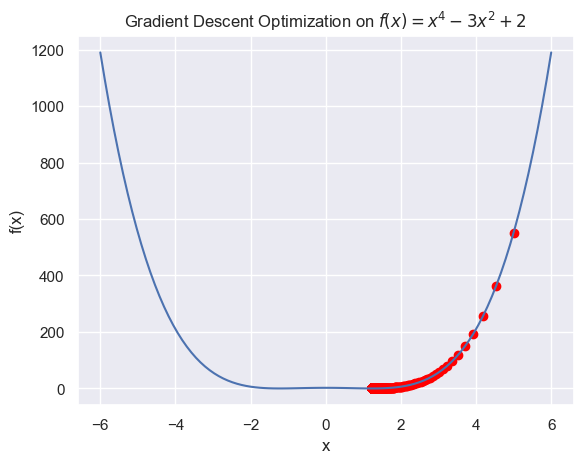

In [18]:
# run gradient descent on f(x) = x^4 - 3x^2 + 2 starting from x = 5 with learning rate (0.001), for 5000 iterations
path3 = gradient_descent(f3, df3, initial_values[2], learning_rates[0], 5000)

x_vals = np.linspace(-6, 6, 100) # generate x values for plotting the function
y_vals = f3(x_vals)              # compute corresponding y values using f(x) = x^4 - 3x^2 + 2

# plot the function curve (blue line)
plt.plot(x_vals, y_vals)

# plot gradient descent steps as red points
plt.scatter(path3, [f3(x) for x in path3], color='red')

plt.title(r"Gradient Descent Optimization on $f(x)=x^4 - 3x^2 + 2$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

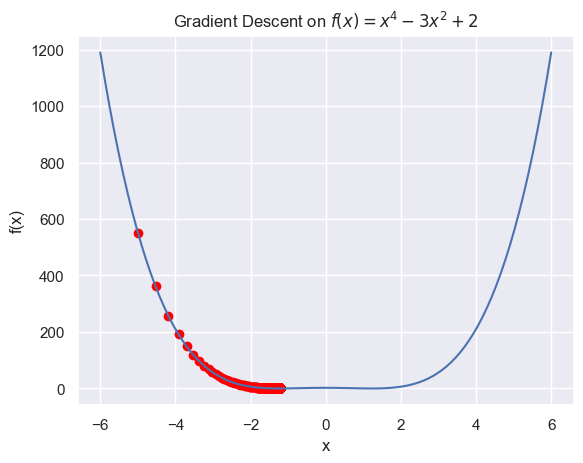

In [19]:
# run gradient descent on f(x) = x^4 - 3x^2 + 2 starting from x = -5 with learning rate (0.001), for 5000 iterations
path3 = gradient_descent(f3, df3, initial_values[0], learning_rates[0], 5000)

x_vals = np.linspace(-6, 6, 100) # generate x values for plotting the function
y_vals = f3(x_vals)              # compute corresponding y values using f(x)

# plot the function curve (blue line)
plt.plot(x_vals, y_vals)

# plot gradient descent steps as red points
plt.scatter(path3, [f3(x) for x in path3], color='red')

plt.title(r"Gradient Descent on $f(x)=x^4 - 3x^2 + 2$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

### 5.4 Sinusoidal Function
$$
f(x) = \sin(2x)\cos(2x) + 0.2x^2
$$

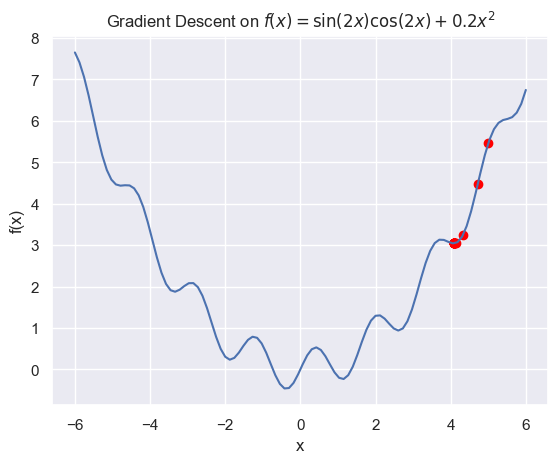

In [20]:
# run gradient descent on f(x) = sin(2x)cos(2x) + 0.2x^2 starting from x = 5 with learning rate (0.1), for 5000 iterations
path4 = gradient_descent(f4, df4, initial_values[2], learning_rates[1], 5000)

x_vals = np.linspace(-6, 6, 100) # generate x values for plotting the function
y_vals = f4(x_vals)              # compute corresponding y values using f(x)

# plot the function curve (blue line)
plt.plot(x_vals, y_vals)

# plot gradient descent steps as red points
plt.scatter(path4, [f4(x) for x in path4], color='red')

plt.title(r"Gradient Descent on $f(x)=\sin(2x)\cos(2x) + 0.2x^2$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

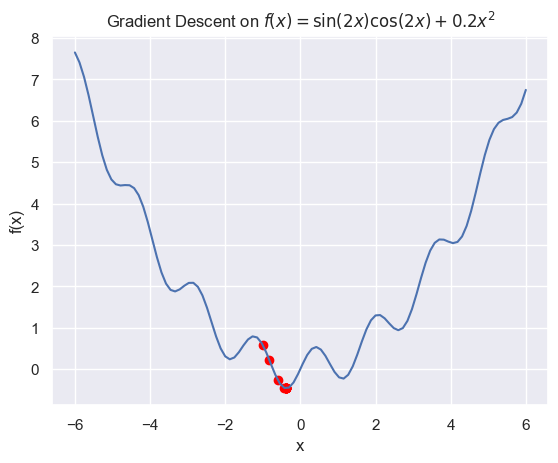

In [21]:
# run gradient descent on f(x) = sin(2x)cos(2x) + 0.2x^2 starting from x = -1 with learning rate (0.1), for 5000 iterations
path4 = gradient_descent(f4, df4, initial_values[1], learning_rates[1], 5000)

x_vals = np.linspace(-6, 6, 100) # generate x values for plotting the function
y_vals = f4(x_vals)              # compute corresponding y values using f(x)

# plot the function curve (blue line)
plt.plot(x_vals, y_vals)

# plot gradient descent steps as red points
plt.scatter(path4, [f4(x) for x in path4], color='red')

plt.title(r"Gradient Descent on $f(x)=\sin(2x)\cos(2x) + 0.2x^2$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()